# 01 · The world (the engine)

**Goal:** open the black box. This notebook *imports the engine* (it does not re-implement it) and
shows, step by step, the data-generating process: who the agents are, what the offers are, how the
choice model turns utilities into conversions (this is our **ground truth**), and what the emitted
**event log** looks like.

Everything here is regenerable from `config.yaml + seed`. The notebook **shows**; the test suite
**guarantees** (`make test`). If a number looks wrong here, it's a real signal — not a slide.

*Layers covered:* `engine/config.py` → `agents.py` → `offers.py` → `choice.py` → `market.py` → the event log.

In [1]:
import nbtools; nbtools.use_repo_root(); nbtools.set_style()
import warnings; warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engine import agents as agents_mod
from engine import offers as offers_mod
from engine.choice import ChoiceModel
from nbtools import BLUE, GREEN, PINK, PURPLE, ORANGE, GRAY

## 1. The config is the single source of truth

**What is the config?** `config.yaml` is a single declarative file holding *every* number that
defines a run — market size, the agent/offer distributions, the choice-model parameters, the
experiments, the metrics. Nothing downstream hard-codes a value; the engine reads it all through
`engine/config.py`. This is the "config-driven, reproducible" discipline that separates a *system*
from a notebook: change the file, not the code.

**Reproducibility — the seed.** A run is a stochastic simulation (we draw agents, sample choices,
draw churn). `meta.seed` initialises the random-number generators, so
$$\text{run} = f(\texttt{config.yaml},\ \texttt{seed})$$
is a *pure function*: same config + same seed ⇒ byte-identical event log, every time. We split the
seed into independent named streams (agents, offers, choice, …) via NumPy's `SeedSequence` so that,
e.g., adding a churn draw never shifts the agent-sampling stream.

**The horizon.** `horizon_days` is the length of the simulated experiment in **daily ticks**. One
tick = one simulated day in which agents arrive, view offers, convert, spend budget, and may churn.
`days=10` here means we watch the marketplace for 10 days (production uses 30–60). The simulated
clock is all that matters — wall-clock time is irrelevant.

**Domain glossary** (the rewarded-UA marketplace, à la Almedia/Freecash):
- **Agent** = a *user* — a reward-seeker who completes offers in exchange for a reward. This is the
  side we *simulate*.
- **Offer** = a single advertiser *campaign task* (e.g. "reach level 10 in this game"). It pays a
  **payout**, costs the user **effort**, shows a **reward**, and has a **budget cap**.
- **Advertiser** = a game/app running campaigns. **Offers nest under advertisers**: each offer
  belongs to exactly one advertiser, and an advertiser typically runs several offers — a one-to-many
  (parent → children) hierarchy. We experiment on the *offer/advertiser* side. An experiment "lives
  on" an advertiser, i.e. its treatment changes that advertiser's offers.
- **Cluster** = a geo/segment grouping of users (the unit for *cluster-randomized* designs). Today
  it's a random label (see notebook 03); giving clusters shared structure is a backlog item.
- **OEC** (Overall Evaluation Criterion) = the primary metric we optimise: **margin per active user**.

In [2]:
cfg = nbtools.world_cfg(seed=7, users=3000, days=10)
print("seed           :", cfg.seed)
print("horizon (days) :", cfg.meta.horizon_days)
print("users / arrivals:", cfg.market.n_users_initial, "/", cfg.market.daily_arrivals)
print("offers / advertisers / clusters:",
      cfg.market.n_offers, "/", cfg.market.n_advertisers, "/", cfg.market.n_clusters)
print("choice model   :", cfg.choice.model,
      f"(β_reward={cfg.choice.beta_reward}, β_effort={cfg.choice.beta_effort}, "
      f"match={cfg.choice.match_weight})")
print("experiments    :", [e.id for e in cfg.experiments.list])

seed           : 7
horizon (days) : 10
users / arrivals: 3000 / 75
offers / advertisers / clusters: 30 / 8 / 60
choice model   : mnl (β_reward=1.0, β_effort=0.8, match=0.6)
experiments    : ['exp_reward_sizing', 'exp_offer_ranking', 'aa_null_1', 'aa_null_2']


**The four experiments we run** (one treatment per advertiser — never stacked):

| id | advertiser | lever (treatment) | interference channel | corrected by |
|---|---|---|---|---|
| `exp_reward_sizing` | adv_A | **+15% reward pass-through** (richer reward) | budget cannibalization | budget-split |
| `exp_offer_ranking` | adv_B | a new **ranker** (sort offers differently) | attention competition | cluster (Phase 2) |
| `aa_null_1` | adv_C | **none** (A/A — identical arms) | — | must *not* flag |
| `aa_null_2` | adv_D | **none** (A/A, *cluster*-randomized) | — | must *not* flag |

The two **A/A nulls** are decoys: arms are identical, so a trustworthy pipeline must return "no
effect." They are our false-positive control. `exp_reward_sizing` is the headline (notebook 02);
`exp_offer_ranking`'s lever is a no-op in the current engine, which we *use* in notebook 03 to expose
a confound. Each experiment is **randomized** either at the **user** level (independent coin flip per
user) or the **cluster** level (whole clusters share an arm).

## 2. The agents — the *simulated* side of the market

Each agent is sampled once at creation from the seeded distributions in `config.agents`. These
traits are the ground-truth "who they are." The distributional choices are deliberate — each is the
standard, *defensible* family for the quantity it models (positivity, skew, support on a simplex,
etc.):

- **Effort budget** $b_i$ — time/attention available per day; the shared resource that drives
  cannibalization. $b_i \sim \mathrm{LogNormal}(\mu,\sigma)$ — lognormal because effort is
  strictly positive and right-skewed (a few power-users, many casual users).
- **Reward sensitivity** $s_i$ — the elasticity multiplier on the reward term in utility.
  $s_i \sim \mathrm{Gamma}(k,\theta)$ — positive, flexible skew; a natural prior for a
  non-negative responsiveness coefficient.
- **Category propensity** $\boldsymbol{p}_i$ — taste weights over the offer categories,
  $\boldsymbol{p}_i \sim \mathrm{Dirichlet}(\boldsymbol{\alpha})$, so $\sum_c p_{ic}=1$ — the
  Dirichlet is *the* distribution over a probability simplex (shares that sum to one).
- **Churn hazard** $h_i$ — baseline daily probability of leaving. $h_i \sim \mathrm{Beta}(a,b)$ —
  bounded in $[0,1]$, which is exactly the support of a probability; with $a{=}1.5,\,b{=}30$ the
  mean is $a/(a{+}b)\approx 4.8\%$/day.

We also carry a **churn-reward protection** parameter: recent rewards lower the hazard
($h_i \to h_i\,[1-\rho\tanh(\text{recent reward})]$), so engaged users churn less — a stylized
retention effect. Each agent also gets a **`cluster_id`** (uniform over `n_clusters`).

In [3]:
pop = agents_mod.build_population(cfg, cfg.rng("agents"))
print(f"built {len(pop):,} agents")
a0 = pop[0]
print("\nexample agent:", a0.user_id, "| cluster", a0.cluster_id)
print(f"  effort_budget_per_day = {a0.effort_budget_per_day:.3f}")
print(f"  reward_sensitivity    = {a0.reward_sensitivity:.3f}")
print(f"  base_churn_hazard     = {a0.base_churn_hazard:.4f}")
print(f"  category_propensity   = {np.round(a0.category_propensity, 3)}  "
      f"(over {list(cfg.market.categories)})")

built 3,000 agents

example agent: u_0000000 | cluster c_0012
  effort_budget_per_day = 0.685
  reward_sensitivity    = 0.336
  base_churn_hazard     = 0.0348
  category_propensity   = [0.019 0.52  0.203 0.013 0.245]  (over ['puzzle', 'casino', 'rpg', 'survey', 'shopping'])


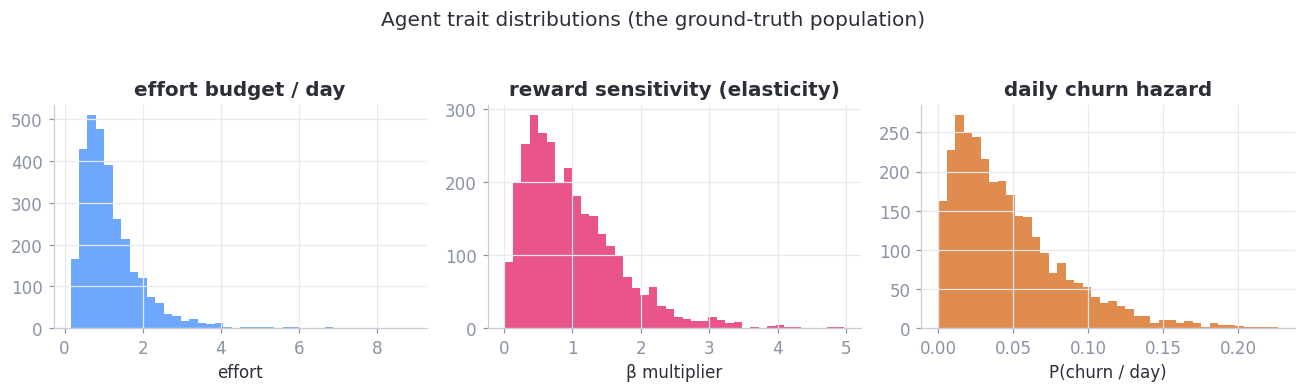

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].hist([a.effort_budget_per_day for a in pop], bins=40, color=BLUE)
ax[0].set_title("effort budget / day"); ax[0].set_xlabel("effort")
ax[1].hist([a.reward_sensitivity for a in pop], bins=40, color=PINK)
ax[1].set_title("reward sensitivity (elasticity)"); ax[1].set_xlabel("β multiplier")
ax[2].hist([a.base_churn_hazard for a in pop], bins=40, color=ORANGE)
ax[2].set_title("daily churn hazard"); ax[2].set_xlabel("P(churn / day)")
fig.suptitle("Agent trait distributions (the ground-truth population)", y=1.04)
plt.tight_layout(); plt.show()

Note the **effort budget** (mean ≈ 1.2) is small relative to a typical offer's effort cost (≈ 2) —
so effort *binds*: most agents complete only a handful of offers a day. That scarcity is what makes
the marketplace interesting (and is one of the two interference channels).

## 3. The offers — the advertiser side

**"Offers nest under advertisers"** means the catalogue is a two-level hierarchy: each *advertiser*
(a game/app) owns one or more *offers* (campaign tasks), and each offer belongs to exactly one
advertiser. So `adv_A` might own offers `of_000, of_012, of_024, …`. This matters because an
**experiment lives on an advertiser** — `exp_reward_sizing` changes *all of adv_A's offers* — while
*other* advertisers' offers are untouched controls.

Each offer $j$ is sampled (seeded) with:
- **payout** $\pi_j \sim \mathrm{LogNormal}$ — what the advertiser pays per completion (positive, skewed);
- **difficulty/effort** $e_j \sim \mathrm{Gamma}$ — the effort a completion costs the user;
- **budget cap** $B_j \sim \mathrm{LogNormal}$ — the daily budget the offer can spend before going
  dark (our `refill: daily` model — see pm/DECISIONS.md D-11);
- a **category** (uniform over `market.categories`).

The user sees a **reward** $r_j = \pi_j \cdot \kappa$ where $\kappa$ is the **pass-through** (default
0.7); the platform keeps the rest, so the **margin** (our OEC's numerator) is
$$\text{margin}_j \;=\; \underbrace{\pi_j}_{\text{payout}} - \underbrace{r_j}_{\text{reward shown}}
  \;=\; \pi_j\,(1-\kappa).$$
A **reward-sizing treatment** raises $\kappa$ (richer reward), which **lowers per-conversion margin**
but makes the offer more attractive (higher conversion) and **depletes the budget faster**. That
three-way tension — margin ↓, volume ↑, budget depletion ↑ — is exactly the reward-sizing trade-off
we measure in notebook 02, and the budget depletion is the interference channel.

In [5]:
offs = offers_mod.build_offers(cfg, cfg.rng("offers"))
odf = pd.DataFrame([{
    "offer": o.offer_id, "advertiser": o.advertiser_id, "category": o.category,
    "payout": o.payout, "reward_shown": o.reward_shown(), "margin": o.payout - o.reward_shown(),
    "effort": o.difficulty_effort, "budget_cap": o.budget_cap,
} for o in offs])
print(f"{len(odf)} offers across {odf.advertiser.nunique()} advertisers")
odf.head(6)

30 offers across 8 advertisers


,offer,advertiser,category,payout,reward_shown,margin,effort,budget_cap
0,of_000,adv_A,survey,4.485971,3.140180,1.345791,2.433268,4598.240375
1,of_001,adv_B,shopping,3.409993,2.386995,1.022998,1.628727,320.064154
2,of_002,adv_C,puzzle,10.258957,7.181270,3.077687,2.189590,1191.653800
3,of_003,adv_D,survey,2.162983,1.514088,0.648895,1.099110,638.647840
4,of_004,adv_E,puzzle,4.235510,2.964857,1.270653,3.370137,199.047014
5,of_005,adv_F,shopping,2.172038,1.520427,0.651612,1.352757,86.004408


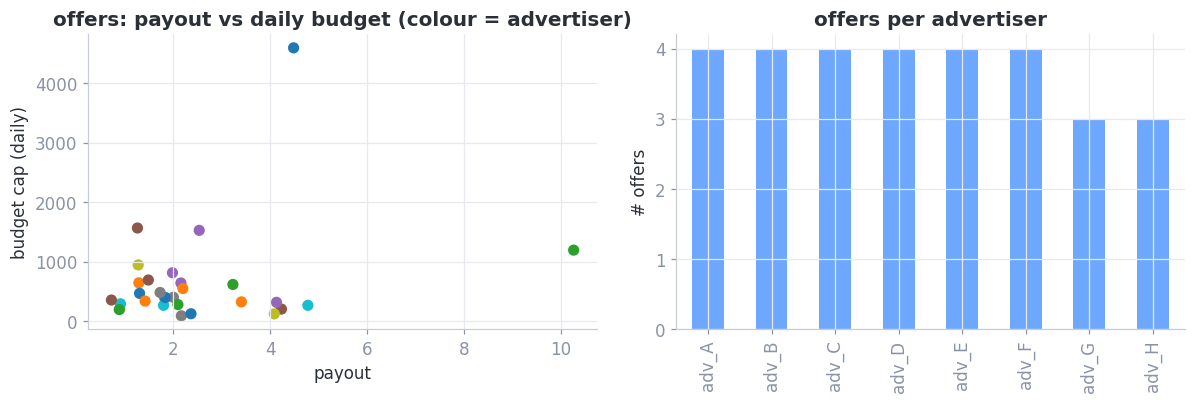

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].scatter(odf.payout, odf.budget_cap, c=odf.advertiser.astype("category").cat.codes,
              cmap="tab10", s=40)
ax[0].set_xlabel("payout"); ax[0].set_ylabel("budget cap (daily)")
ax[0].set_title("offers: payout vs daily budget (colour = advertiser)")
odf.groupby("advertiser").size().plot.bar(ax=ax[1], color=BLUE)
ax[1].set_title("offers per advertiser"); ax[1].set_xlabel(""); ax[1].set_ylabel("# offers")
plt.tight_layout(); plt.show()

## 4. The choice model **is** the ground truth

This is the core idea of the whole project. We model how an agent picks among offers with a
**multinomial logit (MNL)** discrete-choice model (McFadden, 1974). Agent $i$ assigns each offer $j$
a **utility**

$$u_{ij} \;=\; \underbrace{\beta_r\,s_i\,r_j}_{\text{reward} \times \text{sensitivity}}
  \;-\; \underbrace{\beta_e\,e_j}_{\text{effort cost}}
  \;+\; \underbrace{w\,p_{i,\,\mathrm{cat}(j)}}_{\text{taste match}}
  \;+\; \varepsilon_{ij},
  \qquad \varepsilon_{ij} \sim \text{Gumbel}(0,1),$$

and chooses the alternative with the highest utility. We add an **outside option** $u_{i0}=0+
\varepsilon_{i0}$ — "complete nothing this round" — so the model has an *extensive* margin (whether
to convert at all), not just *which* offer. With i.i.d. Gumbel noise this yields the closed-form
**softmax** choice probabilities

$$P(i \text{ picks } j) \;=\; \frac{e^{v_{ij}}}{\;\sum_{k}e^{v_{ik}} + e^{0}\;},
  \qquad v_{ij}=\mathbb{E}[u_{ij}]=u_{ij}-\varepsilon_{ij},$$

where the $+e^0$ in the denominator is the outside option. **Why this is "ground truth":** *we set*
the parameters $(\beta_r,\beta_e,w)$, so we know the exact data-generating process. A treatment is
defined as a **shift to a utility input** (reward sizing raises $r_j$), so the engine can compute the
*true* effect of any change — something you can never do on a real platform, where the counterfactual
is unobserved.

*Sampling note:* we draw choices with the **Gumbel-max trick** (add Gumbel noise to each $v_{ij}$ and
take the argmax) — exactly equivalent to sampling from the softmax, and a few lines of NumPy (no
estimation library needed, since we *generate* rather than *fit*; see `STACK.md`). The MNL/nested-logit
workhorse and its ground-truth role are discussed in Wager, *Causal Inference* (`paper-library/`).

Let's watch one agent decide over the whole wall.

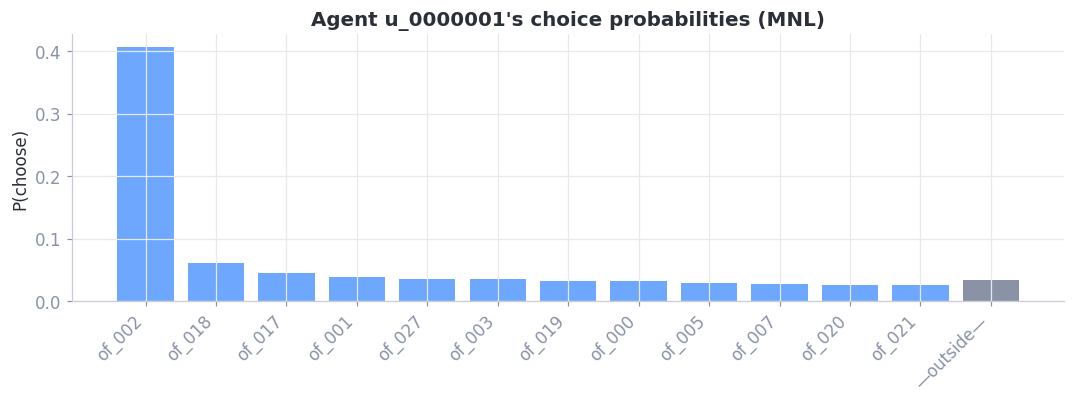

P(complete nothing this round) = 0.034


In [7]:
choice = ChoiceModel(cfg)
agent = pop[1]
rewards = odf.reward_shown.to_numpy()
efforts = odf.effort.to_numpy()
cats = np.array([o.category_index for o in offs])

v = choice.utilities(agent, rewards, efforts, cats)          # deterministic utility per offer
probs = choice.probabilities(v)                              # softmax incl. outside (last entry)

order = np.argsort(v)[::-1][:12]                             # show the 12 most attractive offers
fig, ax = plt.subplots(figsize=(10, 3.8))
labels = [odf.offer.iloc[i] for i in order] + ["—outside—"]
vals = list(probs[order]) + [probs[-1]]
colors = [BLUE] * len(order) + [GRAY]
ax.bar(range(len(vals)), vals, color=colors)
ax.set_xticks(range(len(vals))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("P(choose)"); ax.set_title(f"Agent {agent.user_id}'s choice probabilities (MNL)")
plt.tight_layout(); plt.show()
print(f"P(complete nothing this round) = {probs[-1]:.3f}")

That outside-option probability is why treatments can move the **extensive margin** (whether to
convert at all), not just *which* offer — exactly what a richer reward does.

## 5. Run the engine → the event log

Now we run the full tick loop and read back the **append-only event log** it emits (the only
interface to everything downstream). One file per simulated day, partitioned `day=NN/`.

In [8]:
from engine.market import run
summary = run(cfg, output_dir="events_nb")          # writes events_nb/day=NN/events.parquet
print("event-type counts:", summary["type_counts"])
print("calibration ok   :", summary["calibration"]["ok"])

con = duckdb.connect()
log = con.execute("select * from read_parquet('events_nb/day=*/events.parquet')").df()
print(f"\n{len(log):,} events; columns:")
log[log.event_type == "conversion"][
    ["day", "user_id", "advertiser_id", "offer_id", "experiment_id", "variant",
     "reward_shown", "value", "ground_truth_tau"]
].head(6)

event-type counts: {'arrival': 3675, 'assignment': 14965, 'impression': 15865, 'conversion': 15865, 'budget_decrement': 15865, 'churn': 1016}
calibration ok   : True

67,251 events; columns:


,day,user_id,advertiser_id,offer_id,experiment_id,variant,reward_shown,value,ground_truth_tau
3005,00,u_0001583,adv_C,of_018,aa_null_1,control,1.471187,0.630509,0.000000
3016,00,u_0001694,adv_C,of_002,aa_null_1,control,7.181270,3.077687,0.000000
3019,00,u_0001694,adv_A,of_016,exp_reward_sizing,control,0.917462,0.393198,-0.071536
3022,00,u_0001694,adv_E,of_020,NaN,NaN,0.887196,0.380227,NaN
3029,00,u_0002382,adv_C,of_018,aa_null_1,treatment,1.471187,0.630509,0.000000
3036,00,u_0002963,adv_D,of_003,aa_null_2,treatment,1.514088,0.648895,0.000000


Notice `ground_truth_tau` is populated **only on experiment conversions** — and in `real` mode the
metrics/inference layers never read it (the recovery tests are the only consumer). That hiding rule
is what makes the recovery tests meaningful.

## 6. The marketplace breathes — dynamics over the run

Conversions and the active population over time, plus how much of the daily budget gets consumed.
This is where you'd catch a mis-calibrated world (market collapse = budgets exhaust and everyone
churns). Ours sustains.

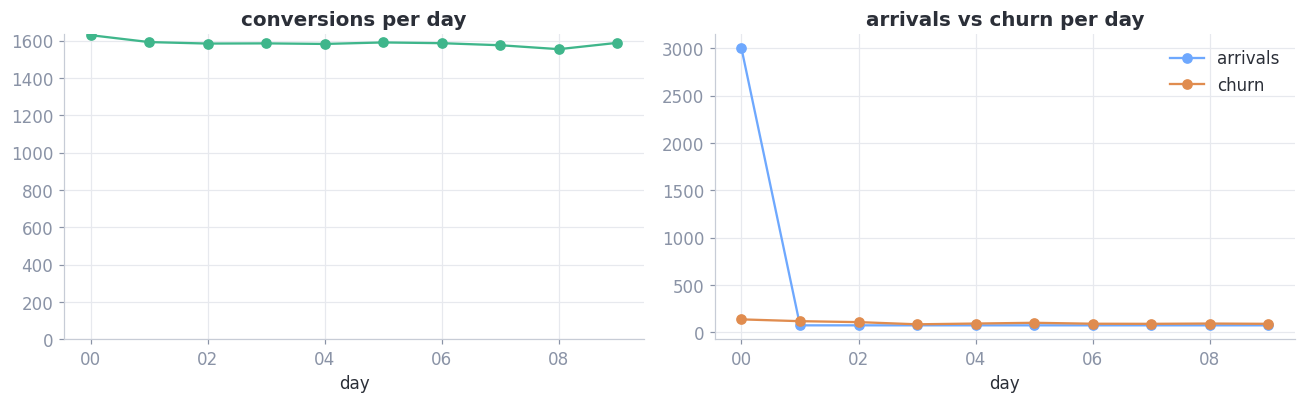

In [9]:
by_day = (log[log.event_type == "conversion"].groupby("day").size().rename("conversions"))
churn = log[log.event_type == "churn"].groupby("day").size().rename("churn")
arr = log[log.event_type == "arrival"].groupby("day").size().rename("arrivals")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
by_day.plot(ax=ax[0], marker="o", color=GREEN); ax[0].set_title("conversions per day")
ax[0].set_xlabel("day"); ax[0].set_ylim(bottom=0)
arr.plot(ax=ax[1], marker="o", color=BLUE, label="arrivals")
churn.plot(ax=ax[1], marker="o", color=ORANGE, label="churn")
ax[1].set_title("arrivals vs churn per day"); ax[1].set_xlabel("day"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Ground truth, distributed

The per-conversion `ground_truth_tau` is the agent-level *local* effect of the reward-sizing
treatment (expected-margin lift, mostly slightly **negative** — richer reward trades margin for
volume). In notebook 02 we go from this local effect to the **global ATE** (the all-treated vs
all-control world gap) and show why the naive estimator can't recover it under interference.

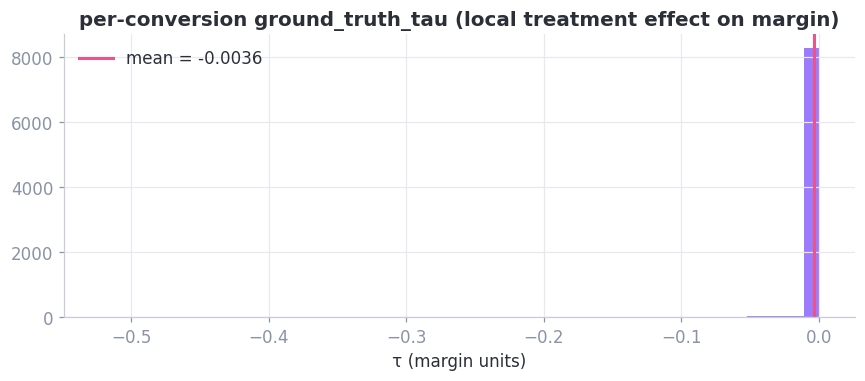

In [10]:
tau = log.loc[log.ground_truth_tau.notna(), "ground_truth_tau"]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(tau, bins=50, color=PURPLE)
ax.axvline(tau.mean(), color=PINK, lw=2, label=f"mean = {tau.mean():+.4f}")
ax.set_title("per-conversion ground_truth_tau (local treatment effect on margin)")
ax.set_xlabel("τ (margin units)"); ax.legend()
plt.tight_layout(); plt.show()

---
**Recap.** Config → seeded agents & offers → an MNL choice model we control (ground truth) → a tick
loop that emits a typed, invariant-checked event log → a marketplace that sustains and breathes.
Nothing hidden. Next: **`02_money_shot.py`** — the headline causal result.

In [11]:
con.close()
import shutil; shutil.rmtree("events_nb", ignore_errors=True)   # tidy the scratch log